In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch import nn
import torch
from torch.utils.data import TensorDataset, DataLoader



device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def calculate_rsi(data, period=14):
    #calculate the relative strength index for an array like over [period] days
    #uses pandas
    delta = pd.DataFrame(data).diff()
    loss = delta.copy()
    gains = delta.copy()
    gains[gains < 0] = 0
    loss[loss > 0] = 0
    gain_wm = gains.rolling(period).apply(lambda x: np.sum(np.abs(x))/period)
    loss_wm = loss.rolling(period).apply(lambda x: np.sum(np.abs(x))/period)
    gpl = gain_wm/loss_wm
    return 100-100/(1+gpl)

# Download data, compute features

In [120]:
url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/master/data/constituents.csv"
sp500 = pd.read_csv(url)

syms_array = sp500.sort_values(by='Date added', axis=0)[:20]['Symbol'].values
syms_list = syms_array.tolist()

In [122]:
train_frac = 0.7
valtest_frac = 0.15


period = 14 #period for technical indicator calculation
prediction_window = 30 #how far ahead to predict directional price movement

train_frames = []
validate_frames = []
test_frames = []

for sym in syms_list:
    tick = yf.Ticker(sym)
    df = tick.history(period='max', interval='1d')

    if df is None or df.empty:
        print('skipping', sym, 'no data found')
        continue

    if 'Close' not in df.columns or 'High' not in df.columns or 'Low' not in df.columns or 'Volume' not in df.columns:
        print('skipping', sym, 'no close found')
        continue

    close = df['Close']
    high = df['High']
    low = df['Low']
    volume = df['Volume']

    smooth = close.ewm(alpha=0.8, adjust=False).mean() #exponential smoothing of data

    indicators = pd.DataFrame() #create the dataframe where the indicators will be calculated

    #simple movingv average
    indicators['sma'] = smooth.rolling(period).mean()

    #stochastic K%
    indicators['stck'] = (smooth - low.rolling(period).min()) / (high.rolling(period).max() - low.rolling(period).min()) * 100

    #stochastic D% 
    indicators['stcd'] = indicators['stck'].rolling(3).sum()/3

    #momentum 
    indicators['mom'] = smooth.diff(period-1)

    #relative strength index
    indicators['rsi'] = calculate_rsi(smooth)

    #moving average convergence divergence
    emas = smooth.ewm(span = 12, adjust=False).mean() - smooth.ewm(span=26, adjust=False).mean()
    indicators['macd'] = emas.ewm(span=9).mean()

    #williams R%
    indicators['lwr'] = -100 * (high.rolling(period).max() - smooth) / (high.rolling(period).max() - low.rolling(period).min())

    #rate of change
    indicators['roc'] = 100 * smooth.diff(period)/smooth.shift(period)

    #Accumulation Distribution Oscillator
    indicators['ado'] = (high-smooth.shift(1))/(high-low) 

    #Commodity Channel Index
    tp = (smooth+high+low)/3
    stp = tp.rolling(period).sum() / period
    d = tp.rolling(period).apply(lambda x: np.mean(np.abs(x-x.mean())))
    indicators['cci'] = (tp-stp)/(0.015*d)

    #on balance volume
    indicators['obv'] = (np.sign(smooth.diff()) * volume).fillna(0).cumsum().pct_change()

    #make target columns
    indicators['target'] = np.sign(close.shift(-prediction_window) - close)

    indicators['symbol'] = sym

    indicators_clean = indicators.dropna()

    train_length = int(len(indicators_clean)*train_frac)
    valtest_length = int(len(indicators_clean)*valtest_frac)

    indicators_clean['stck'] /= np.nanmax(indicators_clean['stck'][:train_length].abs())
    indicators_clean['stcd'] /= np.nanmax(indicators_clean['stcd'][:train_length].abs())
    indicators_clean['lwr'] /= np.nanmax(indicators_clean['lwr'][:train_length].abs())
    indicators_clean['macd'] /= np.nanmax(indicators_clean['macd'][:train_length].abs())
    indicators_clean['roc'] /= np.nanmax(indicators_clean['roc'][:train_length].abs())
    indicators_clean['rsi'] /= np.nanmax(indicators_clean['rsi'][:train_length].abs())
    indicators_clean['sma'] /= np.nanmax(indicators_clean['sma'][:train_length].abs())
    indicators_clean['mom'] /= np.nanmax(indicators_clean['mom'][:train_length].abs())
    indicators_clean['ado'] /= np.nanmax(indicators_clean['ado'][:train_length].abs())
    indicators_clean['cci'] /= np.nanmax(indicators_clean['cci'][:train_length].abs())

    train = indicators_clean[:train_length]
    validate = indicators_clean[train_length:train_length+valtest_length]
    test = indicators_clean[train_length+valtest_length:]

    

    if train.empty or validate.empty or test.empty:
        print('skipping', sym, 'no clean data')
        continue

    train_frames.append(train)
    validate_frames.append(validate)
    test_frames.append(test)

train_indicators = pd.concat(train_frames)
validate_indicators = pd.concat(validate_frames)
test_indicators = pd.concat(test_frames)

print('dataset size:', train_indicators.shape+validate_indicators.shape+test_indicators.shape)

    
    


dataset size: (199032, 13, 42639, 13, 42674, 13)


In [ ]:


n = 14
for tick in df['Close'].columns:
    close = df['Close', tick]
    high = df['High', tick]
    low = df['Low', tick]
    volume = df['Volume', tick]

    smooth = close.ewm(alpha=0.8, adjust=False).mean()

    #10 day simple moving average
    df['SMA', tick] = smooth.rolling(n).mean()

    #stochastic K%
    df['stck', tick] = (smooth - low.rolling(n).min()) / (high.rolling(n).max() - low.rolling(n).min()) * 100

    #stochastic D% 
    df['stcd', tick] = df['stck', tick].rolling(3).sum()/3

    #momentum 
    df['mom', tick] = smooth.diff(n-1)

    #relative strength index
    delta = smooth.diff()
    loss = delta.copy()
    gains = delta.copy()
    gains[gains < 0] = 0
    loss[loss > 0] = 0

    gain_wm = gains.rolling(n).apply(lambda x: np.sum(np.abs(x))/n)
    loss_wm = loss.rolling(n).apply(lambda x: np.sum(np.abs(x))/n)
    gpl = gain_wm/loss_wm
    df['rsi', tick] = 100-100/(1+gpl)

    #moving average convergence divergence
    emas = smooth.ewm(span = 12, adjust=False).mean() - smooth.ewm(span=26, adjust=False).mean()
    df['macd', tick] = emas.ewm(span=9).mean()
    
    #williams R%
    df['lwr', tick] = -100 * (high.rolling(n).max() - smooth) / (high.rolling(n).max() - low.rolling(n).min())

    #rate of change
    df['roc', tick] = 100 * smooth.diff(9)/smooth.shift(9)

    #Accumulation Distribution Oscillator
    df['ado', tick] = (high-smooth.shift(1))/(high-low)

    #Commodity Channel Index
    tp = (smooth+high+low)/3
    stp = tp.rolling(period).sum() / period
    d = m.rolling(n).apply(lambda x: np.mean(np.abs(x-x.mean())))
    df['cci', tick] = (tp-stp)/(0.015*d)

    #on balance volume
    df['obv', tick] = (np.sign(smooth.diff()) * volume).fillna(0).cumsum().pct_change()

    #make target columns
    df['target', tick] = np.sign(close.shift(-30) - close)

    


df['target'] = df['target'].replace(-1, 0)


today = df[-1:]

df = df.replace([np.inf, -np.inf], np.nan)
df2 = df.dropna()

df2['stck'] /= np.nanmax(df['stck'][:int(len(df2)*0.8)].abs())
df2['stcd'] /= np.nanmax(df['stcd'][:int(len(df2)*0.8)].abs())
df2['lwr'] /= np.nanmax(df['lwr'][:int(len(df2)*0.8)].abs())
df2['macd'] /= np.nanmax(df['macd'][:int(len(df2)*0.8)].abs())
df2['roc'] /= np.nanmax(df['roc'][:int(len(df2)*0.8)].abs())
df2['rsi'] /= np.nanmax(df['rsi'][:int(len(df2)*0.8)].abs())
df2['SMA'] /= np.nanmax(df['SMA'][:int(len(df2)*0.8)].abs())
df2['mom'] /= np.nanmax(df['mom'][:int(len(df2)*0.8)].abs())
df2['ado'] /= np.nanmax(df['ado'][:int(len(df2)*0.8)].abs())
df2['cci'] /= np.nanmax(df['cci'][:int(len(df2)*0.8)].abs())



train_data = df2[:int(len(df2)*0.8)]

test_data = df2[int(len(df2)*0.9):]



# Create windows, train/val/test/split, pytorch data sets

In [125]:
train_indicators.drop(columns='target').values

array([[0.013341028649659872, 0.24859129325397356, 0.25856919627226016,
        ..., -0.06560188007642478, 0.17842370887564973, 'MMM'],
       [0.01329922841945886, 0.4116186763602586, 0.31539999878609487,
        ..., -0.04989825831233682, -0.12852128711732635, 'MMM'],
       [0.013274573511481248, 0.5240208654763076, 0.39857235210507175,
        ..., 0.012778145412439133, 0.43838362724232294, 'MMM'],
       ...,
       [0.4277272306377848, 0.563574556898846, 0.5778446478583098, ...,
        0.03398040867829238, 0.03437267140961664, 'CMS'],
       [0.42943089226393244, 0.6306619995044245, 0.5672244679316222, ...,
        0.022695970076361403, 0.028820395787968467, 'CMS'],
       [0.43115668634627136, 0.6473143437089737, 0.6171028612612952, ...,
        0.06359566253267662, 0.005204413317069223, 'CMS']],
      shape=(199032, 12), dtype=object)

In [131]:
window_size=30
X_list=[]
y_list=[]
for sym in syms_list:
    train = train_indicators[train_indicators['symbol']==sym].sort_index()

    indicators = train.drop(columns=['target', 'symbol']).values
    target = train['target'].values
    for i in range(window_size,len(train[:-window_size])):
        X_list.append(indicators[i-window_size:i])
        y_list.append(target[i-1])


X=np.array(X_list,dtype=np.float32)
y=np.array(y_list,dtype=np.float32)
X.shape, y.shape

((197832, 30, 11), (197832,))

In [38]:

n=len(X)
train_end=int(0.7*n)
val_end=int(0.85*n)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

X_train.shape, X_val.shape, X_test.shape

((7989, 30, 10), (1712, 30, 10), (1713, 30, 10))

In [39]:
batch_size = 64
X_train_t=torch.tensor(X_train)
y_train_t=torch.tensor(y_train.reshape(-1,1))
X_val_t=torch.tensor(X_val)
y_val_t=torch.tensor(y_val.reshape(-1,1))
X_test_t=torch.tensor(X_test)
y_test_t=torch.tensor(y_test.reshape(-1,1))

train_loader=DataLoader(TensorDataset(X_train_t,y_train_t),batch_size=batch_size,shuffle=True)
val_loader=DataLoader(TensorDataset(X_val_t,y_val_t),batch_size=batch_size)
test_loader=DataLoader(TensorDataset(X_test_t,y_test_t),batch_size=batch_size)

In [46]:
class LSTMClassifier(nn.Module):
    def __init__(self, feature_dim, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm=nn.LSTM(feature_dim,hidden_size,num_layers,batch_first=True)
        self.fc=nn.Linear(hidden_size,1)
        self.sigmoid=nn.Sigmoid()
    def forward(self,x):
        out,_=self.lstm(x.float())
        out=self.fc(out[:,-1,:])
        return self.sigmoid(out)
    
def train_epoch(model,loader,crit,opt):
    model.train(); total=correct=loss_sum=0
    for xb,yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        pred=model(xb)
        loss=crit(pred,yb)
        loss.backward()
        opt.step()
        loss_sum+=loss.item()*len(xb)
        correct+=((pred>=0.5).float()==yb).sum().item()
        total+=len(xb)
    return loss_sum/total, correct/total

def eval_epoch(model,loader,crit):
    model.eval(); total=correct=loss_sum=0; preds=[]; labels=[]
    with torch.no_grad():
        for xb,yb in loader:
            xb,yb=xb.to(device),yb.to(device)
            pred=model(xb)
            loss=crit(pred,yb)
            loss_sum+=loss.item()*len(xb)
            correct+=((pred>=0.5).float()==yb).sum().item()
            total+=len(xb)
            preds.extend((pred>=0.5).cpu().numpy().astype(int))
            labels.extend(yb.cpu().numpy().astype(int))
    return loss_sum/total, correct/total, preds, labels

In [47]:
X_train_seq=X_train.reshape(-1, 10, window_size)
X_val_seq=X_val.reshape(-1, 10, window_size)
X_test_seq=X_test.reshape(-1, 10, window_size)

train_loader_seq=DataLoader(TensorDataset(torch.tensor(X_train_t),y_train_t),batch_size=batch_size,shuffle=True)
val_loader_seq=DataLoader(TensorDataset(torch.tensor(X_val_t),y_val_t),batch_size=batch_size)
test_loader_seq=DataLoader(TensorDataset(torch.tensor(X_test_t),y_test_t),batch_size=batch_size)

/var/folders/h1/mm8dpz8n5912bh75mydwwcb80000gn/T/ipykernel_8485/2338593345.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_loader_seq=DataLoader(TensorDataset(torch.tensor(X_train_t),y_train_t),batch_size=batch_size,shuffle=True)
/var/folders/h1/mm8dpz8n5912bh75mydwwcb80000gn/T/ipykernel_8485/2338593345.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_loader_seq=DataLoader(TensorDataset(torch.tensor(X_val_t),y_val_t),batch_size=batch_size)
/var/folders/h1/mm8dpz8n5912bh75mydwwcb80000gn/T/ipykernel_8485/2338593345.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True)

In [48]:
lstm=LSTMClassifier(feature_dim=10).to(device)
opt2=torch.optim.Adam(lstm.parameters())
best_l=None; best_val_l=float("inf")
crit=nn.BCELoss()


for epoch in range(1,10):
    tr_l,tr_a=train_epoch(lstm,train_loader_seq,crit,opt2)
    va_l,va_a,_,_=eval_epoch(lstm,val_loader_seq,crit)
    print(f"LSTM {epoch}: Train {tr_l:.4f}/{tr_a:.4f}, Val {va_l:.4f}/{va_a:.4f}")
    if va_l<best_val_l: 
        best_val_l=va_l
        best_l=lstm.state_dict()

lstm.load_state_dict(best_l)

LSTM 1: Train 0.6794/0.5779, Val 0.6732/0.6221
LSTM 2: Train 0.6771/0.5829, Val 0.6761/0.6075
LSTM 3: Train 0.6745/0.5902, Val 0.6700/0.6168
LSTM 4: Train 0.6745/0.5899, Val 0.6716/0.6127
LSTM 5: Train 0.6776/0.5799, Val 0.6710/0.6197
LSTM 6: Train 0.6759/0.5838, Val 0.6733/0.6057
LSTM 7: Train 0.6740/0.5888, Val 0.6795/0.5981
LSTM 8: Train 0.6705/0.5954, Val 0.6873/0.5999
LSTM 9: Train 0.6658/0.5993, Val 0.7480/0.5257


<All keys matched successfully>

In [115]:
opt = yf.Ticker('AAPL').option_chain()

In [268]:
from sklearn.dummy import DummyClassifier


score = []
dummy = DummyClassifier(strategy='most_frequent')
for tick in train_data['Close'].columns:
    x = train_data[[('SMA', tick), ('WMA', tick), ('mom', tick),('rsi', tick), ('lwr', tick), ('macd', tick), 
            ('stck', tick), ('stcd', tick), ('ado', tick), ('cci', tick)]]
    y = train_data['target', tick]

    dummy.fit(x, y)

    test = test_data[[('SMA', tick), ('WMA', tick), ('mom', tick),('rsi', tick), ('lwr', tick), ('macd', tick), 
            ('stck', tick), ('stcd', tick), ('ado', tick), ('cci', tick)]]
    
    test_targets = test_data['target', tick]

    score.append(dummy.score(test, test_targets))

print(np.mean(score), score)

0.5761133603238866 [0.7530364372469636, 0.5141700404858299, 0.5668016194331984, 0.5951417004048583, 0.44534412955465585, 0.6720647773279352, 0.6477732793522267, 0.6396761133603239, 0.3481781376518219, 0.5789473684210527]


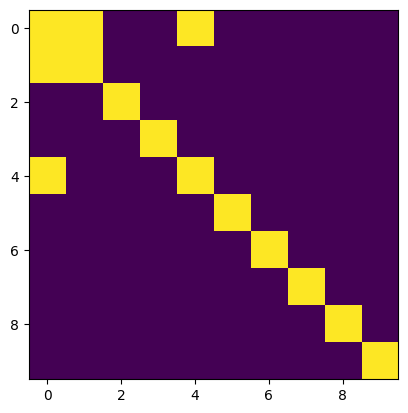

In [266]:
plt.imshow(x.corr()>0.7)